In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,classification_report

In [17]:
df=pd.read_csv('Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [18]:
df.info()
X=df.drop(columns='Species')
y=df['Species']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [32]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.1)
scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [46]:
pca=PCA(n_components=3)
X_train_pca=pca.fit_transform(X_train_scaled)
X_test_pca=pca.transform(X_test_scaled)

knn=KNeighborsClassifier(n_neighbors=3)
knn_pca=knn.fit(X_train_pca,y_train)
y_pred_pca = knn_pca.predict(X_test_pca) 
accuracy_pca=accuracy_score(y_test,y_pred_nor)
print(f"Accuracy Score:{accuracy_pca}")



Accuracy Score:1.0


In [52]:
print("----------------Classification Report--------------\n",classification_report(y_test,y_pred_nor))

----------------Classification Report--------------
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         6
Iris-versicolor       1.00      1.00      1.00         3
 Iris-virginica       1.00      1.00      1.00         6

       accuracy                           1.00        15
      macro avg       1.00      1.00      1.00        15
   weighted avg       1.00      1.00      1.00        15



In [47]:


knn=KNeighborsClassifier(n_neighbors=3)
knn_normal=knn.fit(X_train_scaled,y_train)
y_pred_nor=knn_normal.predict(X_test_scaled)
accuracy=accuracy_score(y_test,y_pred_nor)
print(f"Accuracy Score:{accuracy}")

Accuracy Score:1.0


In [53]:
print("----------------Classification Report--------------\n",classification_report(y_test,y_pred_nor))

----------------Classification Report--------------
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         6
Iris-versicolor       1.00      1.00      1.00         3
 Iris-virginica       1.00      1.00      1.00         6

       accuracy                           1.00        15
      macro avg       1.00      1.00      1.00        15
   weighted avg       1.00      1.00      1.00        15



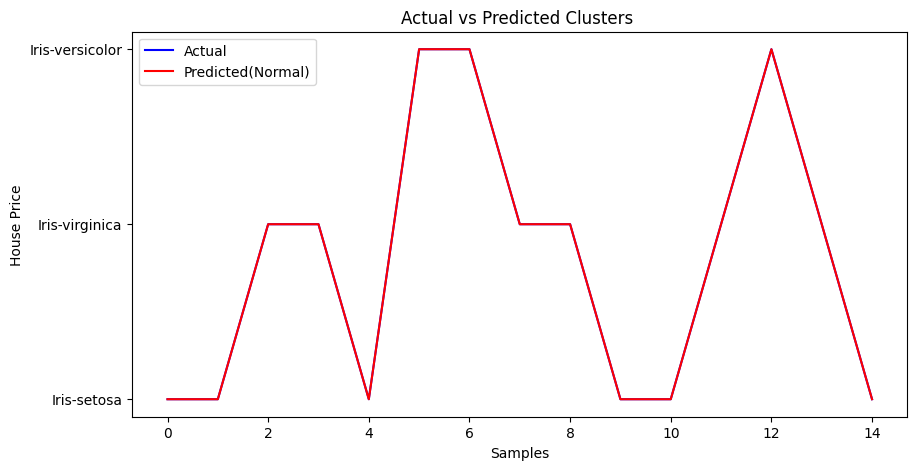

In [55]:
plt.figure(figsize=(10,5))

plt.plot(y_test.values, color='blue', label='Actual')
plt.plot(y_pred_nor, color='red', label='Predicted(Normal)')

plt.xlabel("Samples")
plt.ylabel("House Price")
plt.title("Actual vs Predicted Clusters ")
plt.legend()

plt.show()